<a href="https://colab.research.google.com/github/fatma-hesham2/HEMAYA/blob/main/Helmet%2BVest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# loading Dataset

In [ ]:
!pip install -q roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="PrGfG7reC7eQXsPUP4Bg")

project = rf.workspace("cv-ir5vj").project("worker-hardhat-vest-ldocl")

version = project.version(1)

dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to worker-hardhat-vest-1 in yolov11:: 100%|██████████| 65322/65322 [00:17<00:00, 3801.65it/s]


In [ ]:
print(os.listdir(dataset.location))

['test', 'README.roboflow.txt', 'train', 'data.yaml', 'valid', 'README.dataset.txt']


# Importing

In [ ]:
import os
import yaml
import cv2
import numpy as np
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

DATASET_PATH = "/content/worker-hardhat-vest-1"

# Checking Data Integrity

In [ ]:
with open(os.path.join(DATASET_PATH, "data.yaml"), "r") as f:
    data = yaml.safe_load(f)

print("Number of Classes:", data["nc"])
print("Classes:")
print(data["names"])

Number of Classes: 5
Classes:
['helmet', 'no helmet', 'no vest', 'person', 'vest']


In [ ]:
for split in ["train", "valid", "test"]:

    images_path = os.path.join(DATASET_PATH, split, "images")

    total = len([
        x for x in os.listdir(images_path)
        if x.endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{split}: {total} images")

train: 28491 images
valid: 2730 images
test: 1434 images


In [ ]:
bad_images = []

for split in ["train", "valid", "test"]:

    folder = os.path.join(DATASET_PATH, split, "images")

    for img in tqdm(os.listdir(folder)):

        path = os.path.join(folder, img)

        try:
            Image.open(path).verify()
        except:
            bad_images.append(path)

print("Corrupted Images:", len(bad_images))

100%|██████████| 1434/1434 [00:00<00:00, 13874.42it/s]

Corrupted Images: 0


In [ ]:
missing_labels = []

for split in ["train", "valid", "test"]:

    img_folder = os.path.join(DATASET_PATH, split, "images")
    label_folder = os.path.join(DATASET_PATH, split, "labels")

    for img in os.listdir(img_folder):

        txt = os.path.splitext(img)[0] + ".txt"

        if not os.path.exists(os.path.join(label_folder, txt)):
            missing_labels.append(img)

print("Images without labels:", len(missing_labels))

Images without labels: 0


In [ ]:
bad_labels = []

for split in ["train", "valid", "test"]:

    folder = os.path.join(DATASET_PATH, split, "labels")

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(folder, file)

        with open(path) as f:

            lines = f.readlines()

            for line in lines:

                values = line.strip().split()

                if len(values) != 5:
                    bad_labels.append(path)
                    break

print("Bad Labels:", len(bad_labels))

100%|██████████| 1434/1434 [00:00<00:00, 34731.73it/s]

Bad Labels: 0


In [ ]:
from collections import Counter
from glob import glob
import os

image_counter = Counter()

for split in ["train", "valid", "test"]:

    labels = glob(f"{DATASET_PATH}/{split}/labels/*.txt")

    for file in labels:

        classes_in_image = set()

        with open(file) as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    classes_in_image.add(cls)

        for cls in classes_in_image:
            image_counter[cls] += 1

print("Images containing each class:\n")

for i, name in enumerate(data["names"]):
    print(f"{i:2} {name:<18}: {image_counter[i]}")

Images containing each class:

 0 helmet            : 13892
 1 no helmet         : 2774
 2 no vest           : 2430
 3 person            : 6466
 4 vest              : 9103


In [ ]:
from PIL import Image
from collections import Counter
from glob import glob
import os

sizes = []

train_imgs = glob(os.path.join(DATASET_PATH, 'train', 'images', '*.jpg')) + \
             glob(os.path.join(DATASET_PATH, 'train', 'images', '*.jpeg')) + \
             glob(os.path.join(DATASET_PATH, 'train', 'images', '*.png'))

for img_path in train_imgs:
    try:
        img = Image.open(img_path)
        sizes.append(img.size)
    except Exception as e:
        print("Error:", img_path, e)

size_counts = Counter(sizes)

print("Unique Sizes:")
for size, count in size_counts.items():
    print(size, "->", count, "images")

Unique Sizes:
(640, 640) -> 28491 images


# EDA

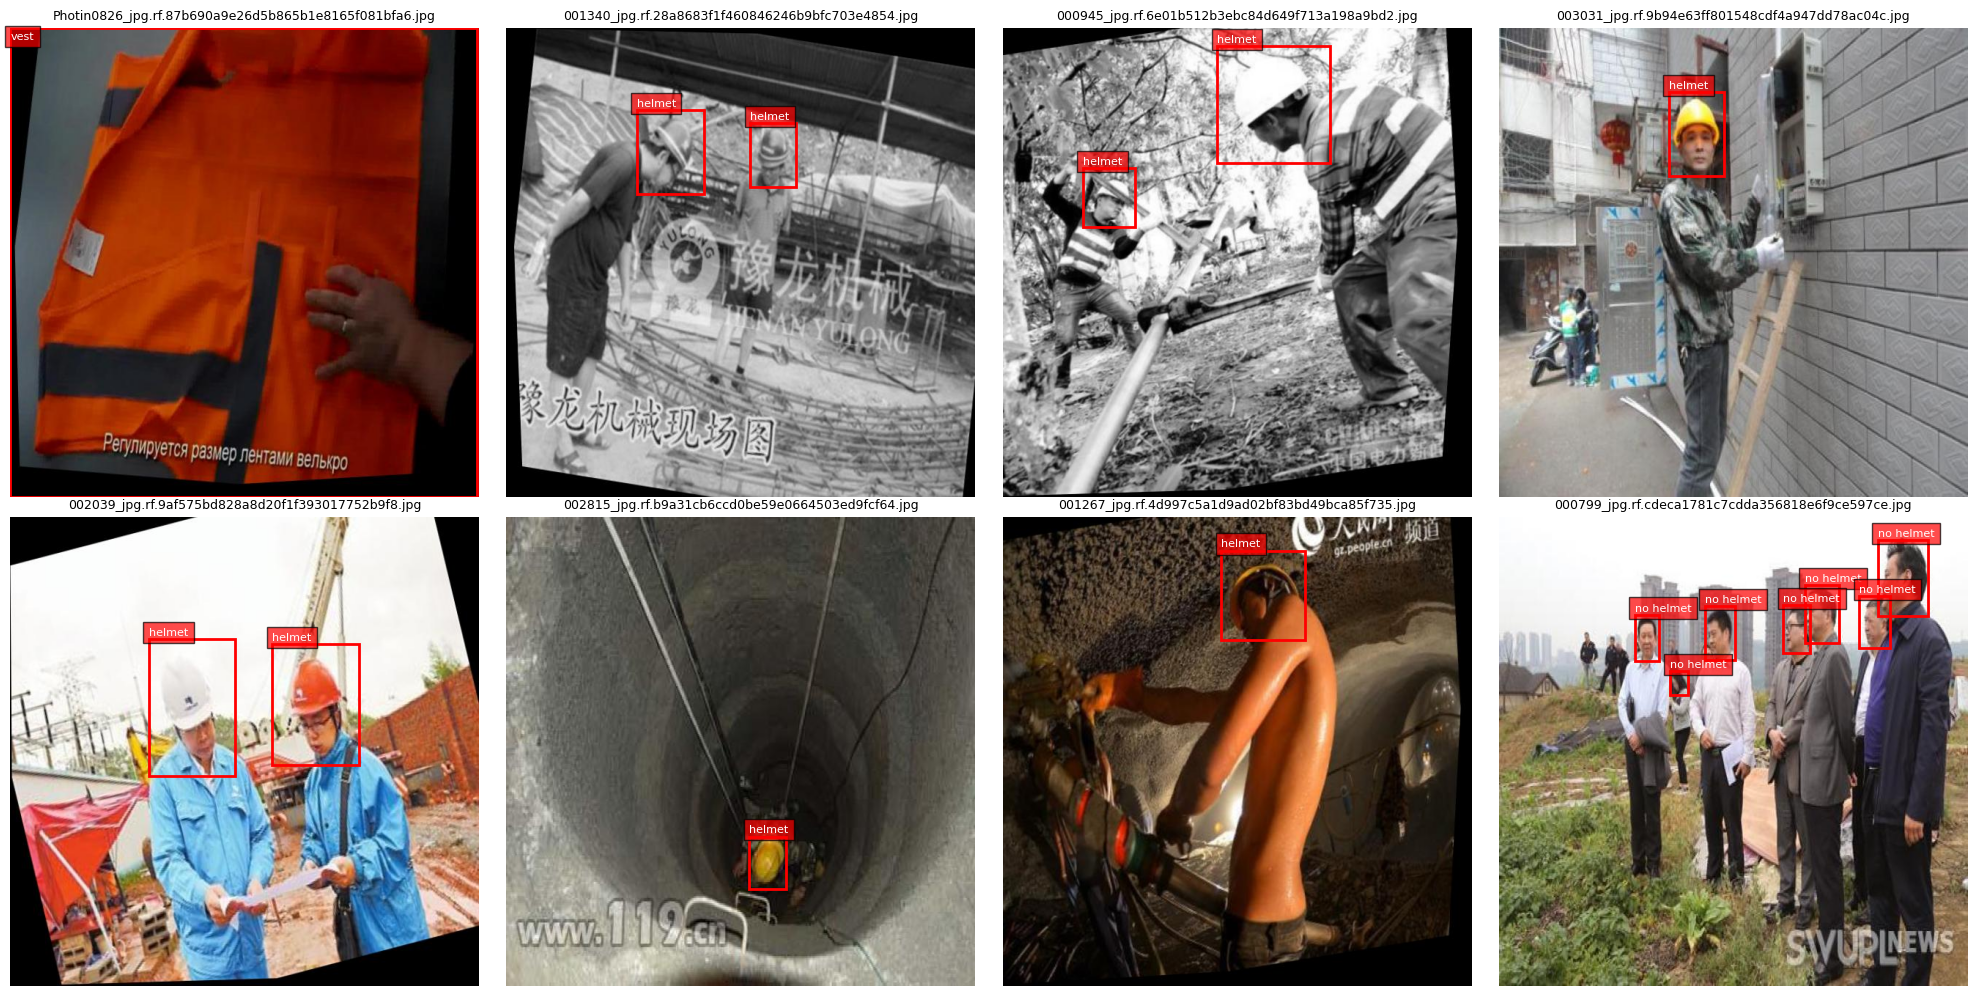

In [ ]:
visualize_samples(
    dataset_path=DATASET_PATH,
    split="train",
    class_names=data["names"],
    n=8
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q ultralytics

# Yolo Training

In [ ]:
from ultralytics import YOLO
import os
model = YOLO('yolo11s.pt')
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
RUNS_DIR = "/content/drive/MyDrive/Himaya/runs"
RUN_NAME = "yolo11s_hardhat_vest"
os.makedirs(RUNS_DIR, exist_ok=True)
results = model.train(
    data=YAML_PATH,

    epochs=75,
    imgsz=640,
    batch=16,

    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,

    warmup_epochs=5,
    patience=15,
    cos_lr=True,

    mosaic=0.7,
    mixup=0.05,
    copy_paste=0.0,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    degrees=5,
    translate=0.1,
    scale=0.3,
    shear=1,

    fliplr=0.5,
    flipud=0.0,

    pretrained=True,
    amp=True,
    cache=False,

    workers=2,


    plots=True,
    save=True,
    save_period=10,

    project=RUNS_DIR,
    name=RUN_NAME,
    exist_ok=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/worker-hardhat-vest-1/data.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.7, multi_scale=0.0, name=yolo11s_hardhat_vest, n

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
!pip install -q ultralytics
from ultralytics import YOLO
checkpoint = "/content/drive/MyDrive/Himaya/runs/yolo11s_hardhat_vest/weights/last.pt"
model = YOLO(checkpoint)
DATASET_PATH = "/content/worker-hardhat-vest-1" # Re-define DATASET_PATH for this cell
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
results = model.train(data=YAML_PATH, resume=True)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/worker-hardhat-vest-1/data.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=/content/drive/MyDrive/Himaya/runs/yolo11s_hardhat_vest/weights/last.pt, momentum=0.9

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q ultralytics roboflow

from ultralytics import YOLO
from roboflow import Roboflow
import os

DATASET_PATH = "/content/worker-hardhat-vest-1"
if not os.path.exists(os.path.join(DATASET_PATH, "data.yaml")):
    print("Dataset not found, re-downloading...")
    rf = Roboflow(api_key="PrGfG7reC7eQXsPUP4Bg")
    project = rf.workspace("cv-ir5vj").project("worker-hardhat-vest-ldocl")
    version = project.version(1)
    dataset = version.download("yolov11")
    print("Dataset re-downloaded.")

model = YOLO("/content/drive/MyDrive/Himaya/runs/yolo11s_hardhat_vest/weights/best.pt")

metrics = model.val(
    data="/content/worker-hardhat-vest-1/data.yaml",
    imgsz=640,
    batch=16
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.7 MB/s eta 0:00:00
Dataset not found, re-downloading...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to worker-hardhat-vest-1 in yolov11:: 100%|██████████| 65322/65322 [00:17<00:00, 3803.98it/s]


Dataset re-downloaded.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1041.1±629.3 MB/s, size: 57.3 KB)
val: Scanning /content/worker-hardhat-vest-1/valid/labels... 2730 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2730/2730 1.6Kit/s 1.7s
val: New cache created: /content/worker-hardhat-vest-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 171/171 12.8s/it 36:21
                   all       2730      17930      0.914      0.878      0.913      0.678
                helmet        548       1720      0.915      0.954      0.964      0.651
             no helmet        109        563      0.885      0.948      0.957      0.681
               no vest        447        562      0.966      0.934      0.962      0.794
                perso

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Himaya/runs/yolo11s_hardhat_vest/weights/best.pt")

results = model.predict(
    source="/content/images (3).jpg",
    conf=0.25,
    imgsz=640,
    save=True,
    show=False
)


image 1/1 /content/images (3).jpg: 384x640 6 helmets, 311.0ms
Speed: 2.8ms preprocess, 311.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-2


In [ ]:
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        print(
            f"Class: {model.names[cls]} | "
            f"Confidence: {conf:.3f}"
        )

Class: helmet | Confidence: 0.845
Class: helmet | Confidence: 0.817
Class: helmet | Confidence: 0.814
Class: helmet | Confidence: 0.774
Class: helmet | Confidence: 0.745
Class: helmet | Confidence: 0.576


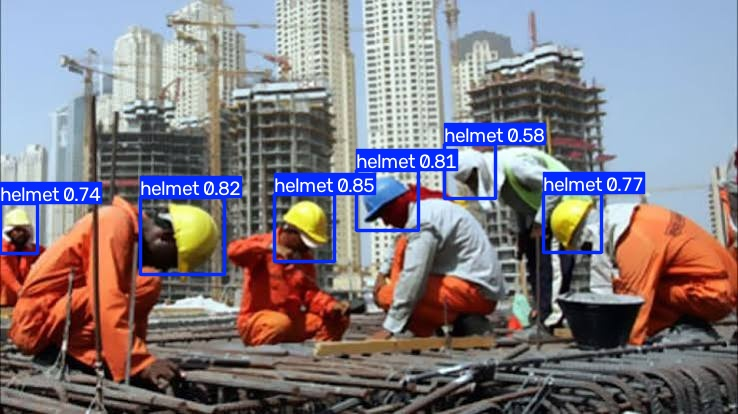

In [ ]:
from IPython.display import Image, display
import glob

result_img = glob.glob("runs/detect/predict*/images (3).jpg")

if result_img:
    display(Image(filename=result_img[-1]))
else:
    print("Prediction image not found.")